In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import Path for clean and reliable file/folder path handling
from pathlib import Path

# Main project dataset location
DATASET_PATH = Path("/content/drive/MyDrive/material_version")

# Prepared Dataset V1 created during Day 11
V1_PATH = DATASET_PATH / "dataset_v1"

# Train, validation and test image folders
TRAIN_DIR = V1_PATH / "train"
VAL_DIR = V1_PATH / "val"
TEST_DIR = V1_PATH / "test"

# Print the paths so we can confirm that Colab is pointing
# to the correct Dataset V1 location
print("Dataset path:", DATASET_PATH)
print("Dataset V1:", V1_PATH)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Dataset path: /content/drive/MyDrive/material_version
Dataset V1: /content/drive/MyDrive/material_version/dataset_v1
Train: /content/drive/MyDrive/material_version/dataset_v1/train
Validation: /content/drive/MyDrive/material_version/dataset_v1/val
Test: /content/drive/MyDrive/material_version/dataset_v1/test


In [5]:
# Check whether all required Dataset V1 folders exist
# before we start any augmentation work.

print("Dataset V1 exists:", V1_PATH.exists())
print("Train folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VAL_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Dataset V1 exists: True
Train folder exists: True
Validation folder exists: True
Test folder exists: True


In [6]:
# Count the image files present in each Dataset V1 split.
# This confirms that the prepared dataset was saved correctly
# and that we are working with the intended Train/Val/Test split.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

train_images = [
    p for p in TRAIN_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

val_images = [
    p for p in VAL_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

test_images = [
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))
print("Total images:", len(train_images) + len(val_images) + len(test_images))

Train images: 5177
Validation images: 943
Test images: 1092
Total images: 7212


In [7]:
# Find all JSON annotation files inside Dataset V1.
# We do this instead of hard-coding filenames, because it lets us
# confirm exactly how the prepared dataset was saved.

json_files = list(V1_PATH.glob("*.json"))

print("JSON files found:", len(json_files))

for file in json_files:
    print("-", file.name)

JSON files found: 1
- preprocessing_config.json


In [8]:
# Dataset V1 keeps the processed annotations separately from
# the train/validation/test image folders.
# We locate all JSON files inside the annotations folder.

ANNOTATIONS_PATH = V1_PATH / "annotations"

annotation_files = list(ANNOTATIONS_PATH.glob("*.json"))

print("Annotation files found:", len(annotation_files))

for file in annotation_files:
    print("-", file.name)

Annotation files found: 3
- instances_train.json
- instances_val.json
- instances_test.json


In [9]:
# Import JSON so we can read the COCO-format annotation files
import json

# Find the three annotation files
annotation_files = list(ANNOTATIONS_PATH.glob("*.json"))

# Print their names so we know which file corresponds to each split
for file in annotation_files:
    print(file.name)

instances_train.json
instances_val.json
instances_test.json


In [10]:
# Import JSON to read the COCO-format annotation files
import json

# Define the exact annotation file paths
TRAIN_JSON = ANNOTATIONS_PATH / "instances_train.json"
VAL_JSON = ANNOTATIONS_PATH / "instances_val.json"
TEST_JSON = ANNOTATIONS_PATH / "instances_test.json"

# Load each annotation file into a Python dictionary
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r") as f:
    val_data = json.load(f)

with open(TEST_JSON, "r") as f:
    test_data = json.load(f)

print("Train annotation file loaded:", TRAIN_JSON.exists())
print("Validation annotation file loaded:", VAL_JSON.exists())
print("Test annotation file loaded:", TEST_JSON.exists())

Train annotation file loaded: True
Validation annotation file loaded: True
Test annotation file loaded: True


In [11]:
# Check the number of images and annotations in each split.
# These numbers should match the Dataset V1 created on Day 11.

print("TRAIN")
print("Images:", len(train_data["images"]))
print("Annotations:", len(train_data["annotations"]))

print("\nVALIDATION")
print("Images:", len(val_data["images"]))
print("Annotations:", len(val_data["annotations"]))

print("\nTEST")
print("Images:", len(test_data["images"]))
print("Annotations:", len(test_data["annotations"]))

TRAIN
Images: 5177
Annotations: 9118

VALIDATION
Images: 943
Annotations: 1390

TEST
Images: 1092
Annotations: 1828


In [12]:
# Create a mapping from category ID to category name.
# This makes the annotation IDs easier to understand in our analysis.

category_map = {
    category["id"]: category["name"]
    for category in train_data["categories"]
}

# Count how many annotated objects belong to each class
from collections import Counter

class_counts = Counter(
    category_map[annotation["category_id"]]
    for annotation in train_data["annotations"]
)

# Print the classes from most frequent to least frequent
print("Final training class distribution:\n")

for class_name, count in class_counts.most_common():
    print(f"{class_name}: {count}")

Final training class distribution:

rov: 2565
trash_etc: 1524
trash_plastic: 1312
trash_metal: 828
animal_fish: 523
plant: 412
animal_starfish: 367
trash_wood: 302
animal_eel: 229
animal_shells: 199
animal_etc: 170
trash_fishing_gear: 165
trash_paper: 163
trash_fabric: 135
trash_rubber: 116
animal_crab: 108


In [13]:
# Calculate the total number of annotated objects in the final training split.
# This should be 9118 based on our Dataset V1 verification.

total_objects = sum(class_counts.values())

print("Total training objects:", total_objects)

# Calculate the percentage of objects belonging to each class.
# This helps us compare classes even though their raw counts are different.

print("\nClass distribution (%):\n")

for class_name, count in class_counts.most_common():
    percentage = (count / total_objects) * 100
    print(f"{class_name}: {count} ({percentage:.2f}%)")

# Calculate the imbalance ratio between the most common
# and least common classes.

max_class = class_counts.most_common(1)[0]
min_class = class_counts.most_common()[-1]

imbalance_ratio = max_class[1] / min_class[1]

print("\nMost common class:", max_class[0], "-", max_class[1])
print("Least common class:", min_class[0], "-", min_class[1])
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

Total training objects: 9118

Class distribution (%):

rov: 2565 (28.13%)
trash_etc: 1524 (16.71%)
trash_plastic: 1312 (14.39%)
trash_metal: 828 (9.08%)
animal_fish: 523 (5.74%)
plant: 412 (4.52%)
animal_starfish: 367 (4.03%)
trash_wood: 302 (3.31%)
animal_eel: 229 (2.51%)
animal_shells: 199 (2.18%)
animal_etc: 170 (1.86%)
trash_fishing_gear: 165 (1.81%)
trash_paper: 163 (1.79%)
trash_fabric: 135 (1.48%)
trash_rubber: 116 (1.27%)
animal_crab: 108 (1.18%)

Most common class: rov - 2565
Least common class: animal_crab - 108
Imbalance ratio: 23.75x


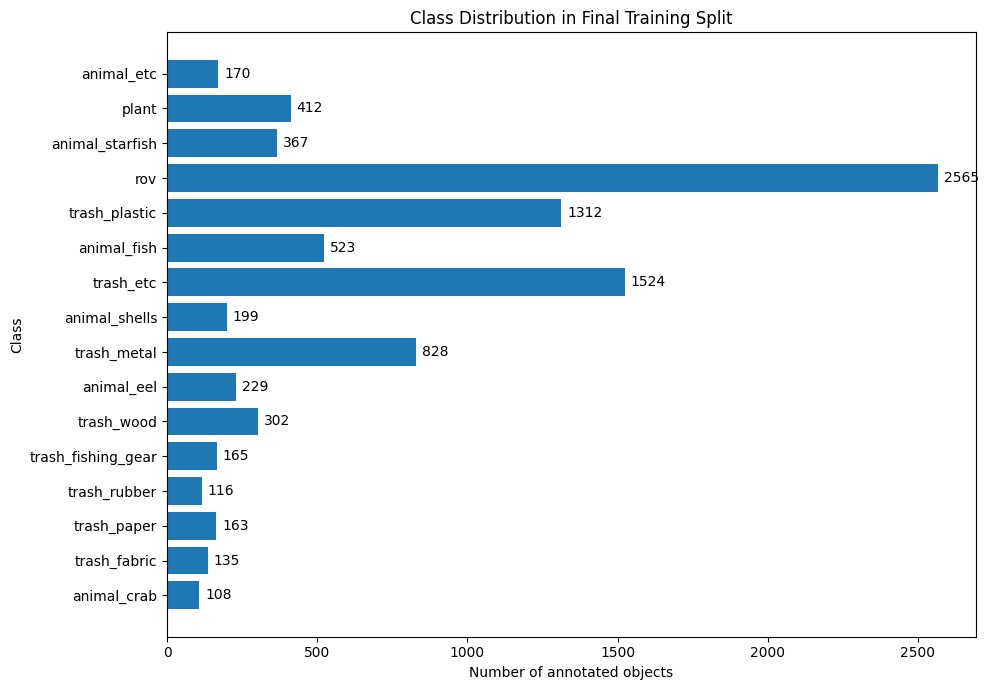

In [14]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Separate class names and their object counts
class_names = list(class_counts.keys())
counts = list(class_counts.values())

# Create a horizontal bar chart
# A horizontal plot makes the class names easier to read.
plt.figure(figsize=(10,7))

plt.barh(class_names, counts)

# Put the most frequent class at the top
plt.gca().invert_yaxis()

plt.xlabel("Number of annotated objects")
plt.ylabel("Class")
plt.title("Class Distribution in Final Training Split")

# Add the exact count beside each bar
for i, count in enumerate(counts):
    plt.text(count + 20, i, str(count), va="center")

plt.tight_layout()
plt.show()

In [15]:
# Calculate the percentage of each object's bounding-box area
# relative to the ORIGINAL image area.
#
# We use the original image dimensions rather than 640x640,
# because Dataset V1 uses letterboxing/padding. Using 640x640
# directly would make objects appear artificially smaller.

# Create a mapping from image ID to its original width and height
image_info = {
    image["id"]: (image["width"], image["height"])
    for image in train_data["images"]
}

# Store the relative area of every training object
relative_areas = []

for annotation in train_data["annotations"]:

    # Get the original image dimensions
    width, height = image_info[annotation["image_id"]]

    # COCO bbox format:
    # [x, y, width, height]
    bbox_width = annotation["bbox"][2]
    bbox_height = annotation["bbox"][3]

    # Calculate bounding-box area
    bbox_area = bbox_width * bbox_height

    # Calculate area relative to the complete original image
    image_area = width * height
    relative_area = bbox_area / image_area

    relative_areas.append(relative_area)

# Count objects smaller than 1% of the image
small_objects = [
    area for area in relative_areas
    if area < 0.01
]

small_count = len(small_objects)
total_count = len(relative_areas)
small_percentage = (small_count / total_count) * 100

print("Total training objects:", total_count)
print("Small objects (<1% image area):", small_count)
print(f"Small-object prevalence: {small_percentage:.2f}%")

Total training objects: 9118
Small objects (<1% image area): 3199
Small-object prevalence: 35.08%


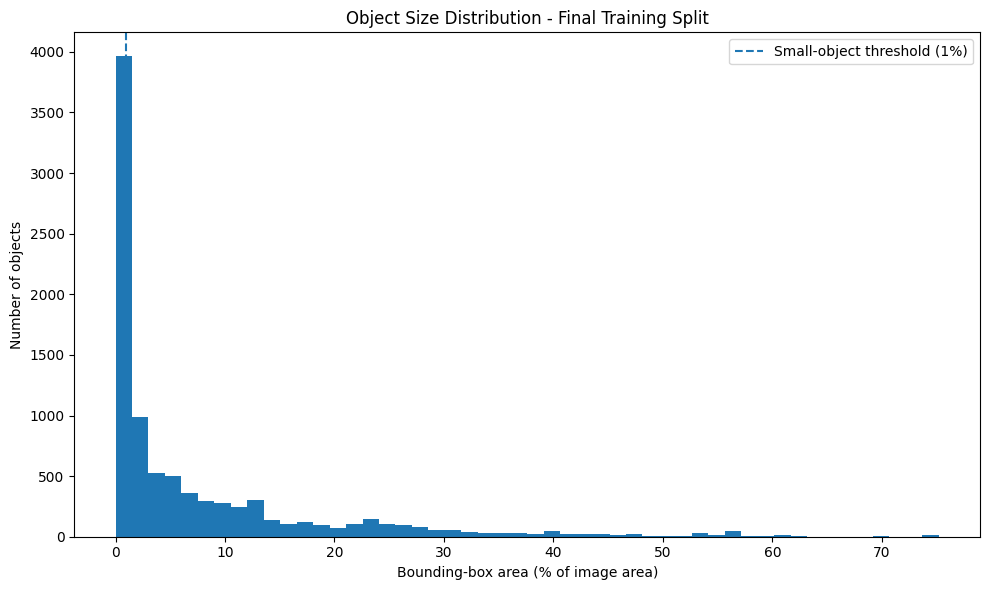

In [16]:
# Visualize the distribution of bounding-box areas relative to
# the original image area.
#
# This helps us understand whether most objects are small,
# medium-sized, or large.

import matplotlib.pyplot as plt

# Convert relative areas into percentages
relative_area_percent = [
    area * 100 for area in relative_areas
]

plt.figure(figsize=(10,6))

plt.hist(relative_area_percent, bins=50)

# Mark the 1% threshold used in our small-object analysis
plt.axvline(
    1,
    linestyle="--",
    label="Small-object threshold (1%)"
)

plt.xlabel("Bounding-box area (% of image area)")
plt.ylabel("Number of objects")
plt.title("Object Size Distribution - Final Training Split")

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Day 13 - Augmentation Configuration
#
# These augmentations are selected based on the visual EDA:
# - Brightness/contrast changes simulate different underwater visibility.
# - Mild color changes simulate variations in underwater color.
# - Horizontal flipping increases spatial variation without changing
#   the size of objects.
# - Mild blur/noise can simulate image degradation, but is kept at
#   low probability because many objects are already very small.
#
# We intentionally avoid:
# - Aggressive cropping
# - Strong blur
# - Vertical flipping
# - Strong geometric distortion
#
# These could make small underwater objects harder to detect.

import albumentations as A

augmentation_pipeline = A.Compose(
    [
        # Horizontal flip with 50% probability
        A.HorizontalFlip(p=0.5),

        # Mild brightness and contrast variation
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        ),

        # Mild underwater color variation
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=15,
            val_shift_limit=10,
            p=0.3
        ),

        # Mild blur with low probability
        A.GaussianBlur(
            blur_limit=(3, 3),
            p=0.1
        ),

        # Mild sensor/compression-like noise with low probability
        A.GaussNoise(
            std_range=(0.01, 0.03),
            p=0.1
        )
    ]
)

print("Augmentation pipeline created successfully.")

Augmentation pipeline created successfully.


In [18]:
# Day 13 - Augmentation Verification
#
# We test the augmentation pipeline on one real training image.
# The goal is to verify that geometric transformations such as
# horizontal flipping keep the bounding boxes aligned with the image.

import cv2
import matplotlib.pyplot as plt

# Select one training image from Dataset V1
sample_image_info = train_data["images"][0]

sample_image_id = sample_image_info["id"]
sample_image_name = sample_image_info["file_name"]

# Dataset V1 stores the processed images inside the train folder
sample_image_path = TRAIN_DIR / Path(sample_image_name).name

# Load the image
image = cv2.imread(str(sample_image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image:", sample_image_name)
print("Shape:", image.shape)

# Get all annotations belonging to this image
sample_annotations = [
    ann for ann in train_data["annotations"]
    if ann["image_id"] == sample_image_id
]

print("Objects in this image:", len(sample_annotations))

Image: vid_000421_frame0000005.jpg
Shape: (640, 640, 3)
Objects in this image: 1


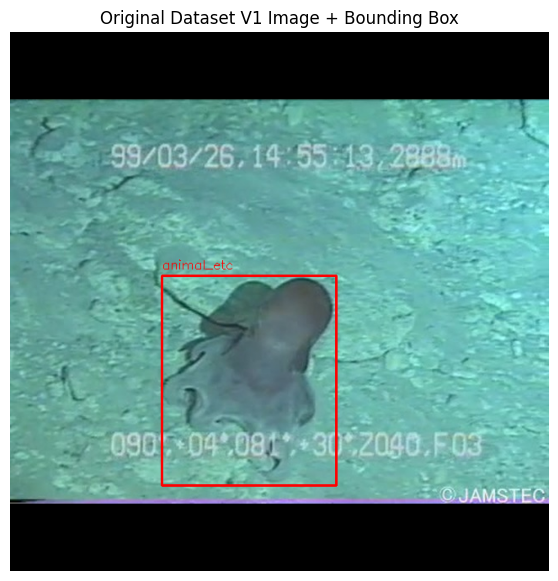

In [19]:
# Day 13 - Visualize Original Annotation
#
# COCO bounding boxes are stored as:
# [x, y, width, height]
#
# We draw the bounding box on the original Dataset V1 image
# so that we can later compare it with the augmented image.

# Make a copy so that the original image remains unchanged
original_image = image.copy()

for ann in sample_annotations:

    # Extract the COCO bounding box
    x, y, w, h = ann["bbox"]

    # Convert coordinates to integers for drawing
    x1 = int(x)
    y1 = int(y)
    x2 = int(x + w)
    y2 = int(y + h)

    # Draw the bounding box
    cv2.rectangle(
        original_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Get the class name
    class_name = category_map[ann["category_id"]]

    # Write the class name above the box
    cv2.putText(
        original_image,
        class_name,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

# Display the annotated image
plt.figure(figsize=(7,7))
plt.imshow(original_image)
plt.axis("off")
plt.title("Original Dataset V1 Image + Bounding Box")
plt.show()

In [20]:
# Day 13 - Apply Augmentation to Image + Bounding Box
#
# We apply the augmentation pipeline to one real training sample.
# Albumentations will transform the image and bounding box together.
#
# This is only a verification test. We are NOT modifying Dataset V1 yet.

import albumentations as A

# Create a simple test pipeline containing only a horizontal flip.
# Keeping this separate makes it easy to verify the geometric
# transformation before testing the complete augmentation pipeline.

test_augmentation = A.Compose(
    [
        A.HorizontalFlip(p=1.0)
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"]
    )
)

# Extract bounding boxes and class names from our sample annotations
sample_bboxes = [
    ann["bbox"]
    for ann in sample_annotations
]

sample_labels = [
    category_map[ann["category_id"]]
    for ann in sample_annotations
]

# Apply the transformation to both image and bounding boxes
augmented = test_augmentation(
    image=image,
    bboxes=sample_bboxes,
    class_labels=sample_labels
)

augmented_image = augmented["image"]
augmented_bboxes = augmented["bboxes"]

print("Original image shape:", image.shape)
print("Augmented image shape:", augmented_image.shape)

print("\nOriginal bounding box:")
print(sample_bboxes[0])

print("\nAugmented bounding box:")
print(augmented_bboxes[0])

Original image shape: (640, 640, 3)
Augmented image shape: (640, 640, 3)

Original bounding box:
[180.0050125313283, 289.33850129198964, 207.97117794486212, 249.32107317609547]

Augmented bounding box:
[252.02381134033203, 289.33849334716797, 207.97115325927734, 249.32106018066406]


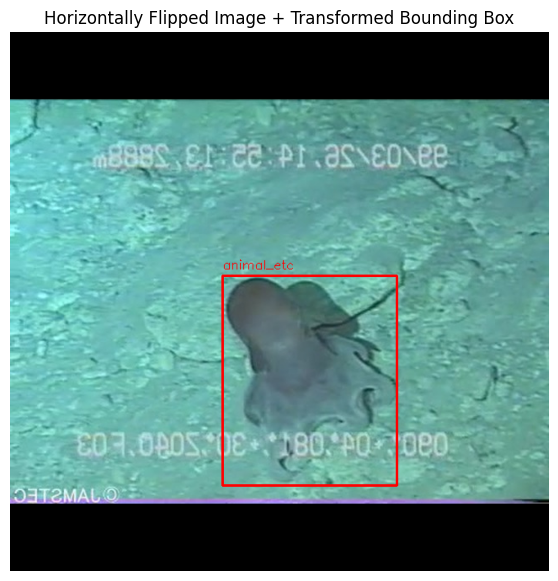

In [21]:
# Day 13 - Visual Verification of Bounding Box Transformation
#
# We display the horizontally flipped image and draw the
# transformed bounding box on it.
#
# If the box is still correctly surrounding the object,
# our geometric augmentation is working correctly.

# Make a copy of the augmented image
verified_image = augmented_image.copy()

# Draw every transformed bounding box
for bbox, class_name in zip(augmented_bboxes, sample_labels):

    # Albumentations returned COCO format:
    # [x, y, width, height]
    x, y, w, h = bbox

    x1 = int(x)
    y1 = int(y)
    x2 = int(x + w)
    y2 = int(y + h)

    # Draw transformed bounding box
    cv2.rectangle(
        verified_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Draw class name
    cv2.putText(
        verified_image,
        class_name,
        (x1, max(y1 - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

# Display the augmented image with its transformed annotation
plt.figure(figsize=(7,7))
plt.imshow(verified_image)
plt.axis("off")
plt.title("Horizontally Flipped Image + Transformed Bounding Box")
plt.show()

In [22]:
# Day 13 - Test Photometric Augmentations
#
# These augmentations change only the appearance of the image.
# They do NOT change the position or size of objects.
#
# Therefore, the bounding boxes should remain unchanged.

import albumentations as A

# Create the photometric augmentation pipeline
# without any geometric transformation.
photometric_augmentation = A.Compose([

    # Simulates brighter or darker underwater scenes
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=1.0
    ),

    # Simulates mild underwater color variation
    A.HueSaturationValue(
        hue_shift_limit=8,
        sat_shift_limit=15,
        val_shift_limit=10,
        p=1.0
    ),

    # Simulates mild image blur
    A.GaussianBlur(
        blur_limit=(3,3),
        p=1.0
    ),

    # Simulates mild sensor/compression noise
    A.GaussNoise(
        std_range=(0.01,0.03),
        p=1.0
    )
])

# Apply the photometric transformations to the image.
# Bounding boxes are passed through unchanged because
# these transformations do not alter image geometry.
photometric_result = photometric_augmentation(
    image=image
)

photometric_image = photometric_result["image"]

print("Original image shape:", image.shape)
print("Augmented image shape:", photometric_image.shape)

# The bounding box remains the original bounding box.
print("\nBounding box before augmentation:")
print(sample_bboxes[0])

print("\nBounding box after photometric augmentation:")
print(sample_bboxes[0])

Original image shape: (640, 640, 3)
Augmented image shape: (640, 640, 3)

Bounding box before augmentation:
[180.0050125313283, 289.33850129198964, 207.97117794486212, 249.32107317609547]

Bounding box after photometric augmentation:
[180.0050125313283, 289.33850129198964, 207.97117794486212, 249.32107317609547]


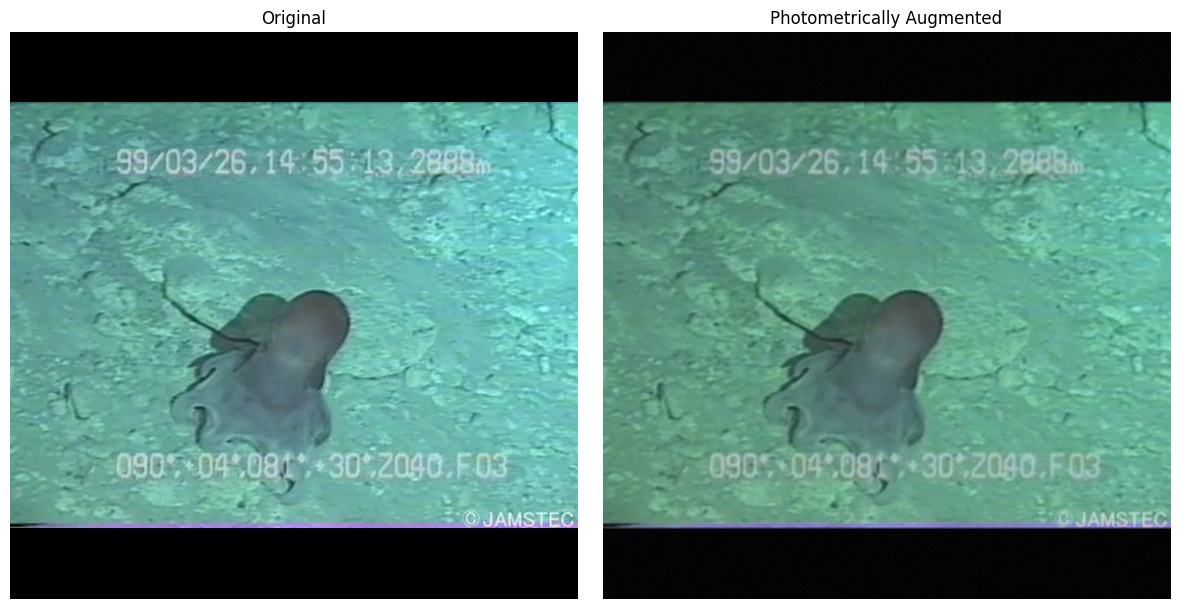

In [23]:
# Day 13 - Visual comparison of photometric augmentation
#
# We compare the original image with the augmented image
# to check whether the transformation is realistic and
# whether the object remains visible.

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(photometric_image)
plt.axis("off")
plt.title("Photometrically Augmented")

plt.tight_layout()
plt.show()

In [24]:
# Day 13 - Inspect Segmentation Annotation
#
# Dataset V1 retains the original segmentation information.
# Before transforming it, we check how the polygon is stored
# in the COCO annotation.

for ann in sample_annotations:
    print("Segmentation data:")
    print(ann["segmentation"])
    print("\nNumber of polygon points:",
          len(ann["segmentation"][0]) // 2)

Segmentation data:
[[320.0, 538.6595744680851, 333.3333333333333, 533.3066666666666, 341.32956685499056, 520.0, 341.32804232804233, 505.3333333333333, 337.3307086614173, 497.3333333333333, 339.9963963963964, 473.3333333333333, 360.0, 463.9047619047619, 367.9487179487179, 453.3333333333333, 366.66115702479334, 437.3333333333333, 362.64, 425.3333333333333, 353.33071895424837, 416.0, 358.6575342465753, 410.66666666666663, 365.3, 398.66666666666663, 366.6640522875817, 376.0, 381.32666666666665, 360.0, 387.9761904761904, 342.66666666666663, 387.91666666666663, 321.3333333333333, 383.9969135802469, 309.3333333333333, 370.66666666666663, 294.68888888888887, 361.3333333333333, 289.33850129198964, 346.66666666666663, 289.34502923976606, 333.3333333333333, 292.1111111111111, 309.3333333333333, 304.0042735042735, 296.005698005698, 320.0, 285.33601070950465, 345.3333333333333, 280.0, 350.66928104575163, 257.3333333333333, 356.00261437908495, 238.66666666666666, 357.3386243386243, 221.3333333333333

In [27]:
# Day 13 - Segmentation Transformation Verification
#
# The Dataset V1 annotations contain segmentation polygons.
# When we horizontally flip an image, every polygon point must
# also be horizontally flipped.
#
# We will:
# 1. Extract the polygon points.
# 2. Apply the same horizontal flip to those points.
# 3. Draw the transformed polygon on the flipped image.
# 4. Visually check that it remains aligned with the object.

# Create a transformation specifically for polygon/keypoint coordinates
segmentation_transform = A.Compose(
    [
        A.HorizontalFlip(p=1.0)
    ],
    keypoint_params=A.KeypointParams(
        format="xy"
    )
)

# Get the segmentation polygons from the sample annotation
sample_segmentation = sample_annotations[0]["segmentation"]

# Convert all polygon coordinates into (x, y) points
all_points = []

for polygon in sample_segmentation:
    points = [
        (polygon[i], polygon[i + 1])
        for i in range(0, len(polygon), 2)
    ]
    all_points.extend(points)

# Apply the same horizontal flip to all polygon points
segmentation_result = segmentation_transform(
    image=image,
    keypoints=all_points
)

transformed_points = segmentation_result["keypoints"]

# Reconstruct the polygons using the transformed points
transformed_segmentation = []

point_index = 0

for polygon in sample_segmentation:

    # Number of points in this polygon
    num_points = len(polygon) // 2

    # Get the transformed points belonging to this polygon
    polygon_points = transformed_points[
        point_index:point_index + num_points
    ]

    # Convert (x, y) points back to COCO's flat format
    flat_polygon = []

    for x, y in polygon_points:
        flat_polygon.extend([x, y])

    transformed_segmentation.append(flat_polygon)

    point_index += num_points

print("Original polygon components:", len(sample_segmentation))
print("Transformed polygon components:", len(transformed_segmentation))

print("\nOriginal first point:")
print(sample_segmentation[0][:2])

print("\nTransformed first point:")
print(transformed_segmentation[0][:2])

Original polygon components: 2
Transformed polygon components: 2

Original first point:
[320.0, 538.6595744680851]

Transformed first point:
[319.0, 538.6595458984375]


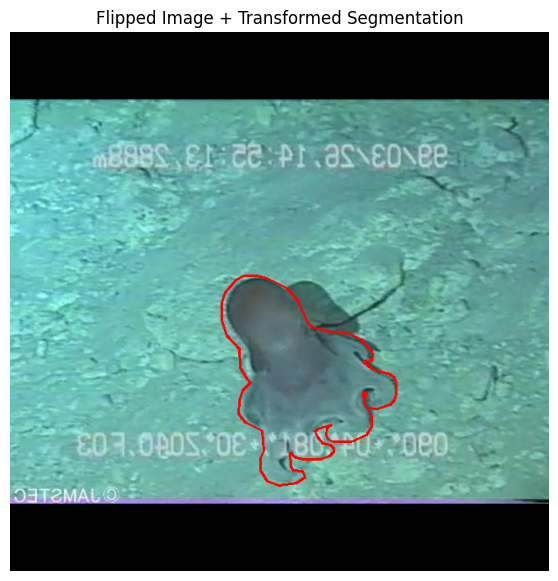

In [29]:
# Day 13 - Visual Segmentation Verification
#
# Draw the transformed segmentation polygons on the horizontally
# flipped image.
#
# The polygon should remain exactly over the object.

# Start with the previously augmented/flipped image
segmentation_check_image = augmented_image.copy()

# Draw each transformed polygon
import numpy as np
for polygon in transformed_segmentation:

    # Convert the flat COCO polygon into OpenCV point format
    points = np.array(
        [
            [polygon[i], polygon[i + 1]]
            for i in range(0, len(polygon), 2)
        ],
        dtype=np.int32
    )

    # Draw the polygon outline
    cv2.polylines(
        segmentation_check_image,
        [points],
        isClosed=True,
        color=(255, 0, 0),
        thickness=2
    )

# Display the result
plt.figure(figsize=(7, 7))
plt.imshow(segmentation_check_image)
plt.axis("off")
plt.title("Flipped Image + Transformed Segmentation")
plt.show()

In [30]:
# Day 13 - Final Augmentation Configuration
#
# This is the augmentation policy we will use for training.
# The choices are based on the image-quality and small-object
# findings from our Day 10 and Day 13 analysis.
#
# Important:
# Augmentation will be applied ONLY to the training data.
# Validation and test images will remain unchanged.

final_augmentation = A.Compose(
    [
        # Simulate objects appearing from different horizontal directions
        A.HorizontalFlip(p=0.5),

        # Simulate changes in underwater brightness and visibility
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        ),

        # Simulate mild underwater color variation
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=15,
            val_shift_limit=10,
            p=0.3
        ),

        # Simulate mild optical blur
        # Kept at low probability because many objects are small
        A.GaussianBlur(
            blur_limit=(3, 3),
            p=0.1
        ),

        # Simulate mild image/sensor noise
        A.GaussNoise(
            std_range=(0.01, 0.03),
            p=0.1
        )
    ]
)

print("Final augmentation policy created.")

Final augmentation policy created.


In [31]:
# Day 13 - Save Augmentation Configuration
#
# Saving the configuration makes the experiment reproducible.
# Later we can look at this file and know exactly which
# augmentations were used.

import json

augmentation_config = {
    "dataset": "TrashCAN material_version Dataset V1",
    "image_size": [640, 640],

    "augmentation_split": "train_only",

    "augmentations": {
        "horizontal_flip": {
            "probability": 0.5
        },
        "brightness_contrast": {
            "probability": 0.5,
            "brightness_limit": 0.15,
            "contrast_limit": 0.15
        },
        "hue_saturation": {
            "probability": 0.3,
            "hue_shift_limit": 8,
            "saturation_shift_limit": 15,
            "value_shift_limit": 10
        },
        "gaussian_blur": {
            "probability": 0.1,
            "blur_limit": [3, 3]
        },
        "gaussian_noise": {
            "probability": 0.1,
            "std_range": [0.01, 0.03]
        }
    },

    "disabled_augmentations": [
        "random_crop",
        "vertical_flip",
        "strong_geometric_distortion"
    ],

    "reason": "Mild augmentations selected based on underwater visibility variation and 35.08% small-object prevalence."
}

# Save the configuration inside Dataset V1
AUG_CONFIG_PATH = V1_PATH / "augmentation_config.json"

with open(AUG_CONFIG_PATH, "w") as f:
    json.dump(augmentation_config, f, indent=4)

print("Configuration saved to:")
print(AUG_CONFIG_PATH)

Configuration saved to:
/content/drive/MyDrive/material_version/dataset_v1/augmentation_config.json


In [32]:
# Day 13 - Final Training Configuration
#
# This configuration records the dataset version, image size,
# class names and train/validation/test split that will be used
# for the YOLO baseline.
#
# The original Dataset V1 and COCO annotations are NOT modified.

training_config = {
    # Dataset information
    "dataset": "TrashCAN material_version",
    "dataset_version": "Dataset V1",

    # Image preprocessing
    "image_size": [640, 640],
    "resize_method": "aspect_ratio_preserving_letterbox",

    # Final leakage-safe split
    "train_images": 5177,
    "validation_images": 943,
    "test_images": 1092,

    # Final annotation counts
    "train_annotations": 9118,
    "validation_annotations": 1390,
    "test_annotations": 1828,

    # Number of classes
    "num_classes": 16,

    # Classes in the original category-ID order
    "class_names": [
        "rov",
        "plant",
        "animal_fish",
        "animal_starfish",
        "animal_shells",
        "animal_crab",
        "animal_eel",
        "animal_etc",
        "trash_etc",
        "trash_fabric",
        "trash_fishing_gear",
        "trash_metal",
        "trash_paper",
        "trash_plastic",
        "trash_rubber",
        "trash_wood"
    ],

    # Augmentation policy
    "augmentation": "training_only",

    # Keep validation and test data unchanged
    "validation_augmentation": False,
    "test_augmentation": False,

    # Keep segmentation information available for future use
    "segmentation_retained": True
}

# Save the final training configuration
TRAIN_CONFIG_PATH = V1_PATH / "training_config.json"

with open(TRAIN_CONFIG_PATH, "w") as f:
    json.dump(training_config, f, indent=4)

print("Final training configuration saved.")
print(TRAIN_CONFIG_PATH)

Final training configuration saved.
/content/drive/MyDrive/material_version/dataset_v1/training_config.json


In [33]:
# Day 13 - Final Configuration Summary
#
# Print the important settings that will be used for the
# upcoming YOLO baseline.

print("===== DATASET V1 TRAINING CONFIGURATION =====")

print("Image size:", training_config["image_size"])
print("Resize method:", training_config["resize_method"])

print("\nSplit:")
print("Train:", training_config["train_images"], "images")
print("Validation:", training_config["validation_images"], "images")
print("Test:", training_config["test_images"], "images")

print("\nAnnotations:")
print("Train:", training_config["train_annotations"])
print("Validation:", training_config["validation_annotations"])
print("Test:", training_config["test_annotations"])

print("\nNumber of classes:", training_config["num_classes"])

print("\nClasses:")
for i, name in enumerate(training_config["class_names"]):
    print(i, "-", name)

print("\nAugmentation:", training_config["augmentation"])
print("Segmentation retained:", training_config["segmentation_retained"])

===== DATASET V1 TRAINING CONFIGURATION =====
Image size: [640, 640]
Resize method: aspect_ratio_preserving_letterbox

Split:
Train: 5177 images
Validation: 943 images
Test: 1092 images

Annotations:
Train: 9118
Validation: 1390
Test: 1828

Number of classes: 16

Classes:
0 - rov
1 - plant
2 - animal_fish
3 - animal_starfish
4 - animal_shells
5 - animal_crab
6 - animal_eel
7 - animal_etc
8 - trash_etc
9 - trash_fabric
10 - trash_fishing_gear
11 - trash_metal
12 - trash_paper
13 - trash_plastic
14 - trash_rubber
15 - trash_wood

Augmentation: training_only
Segmentation retained: True


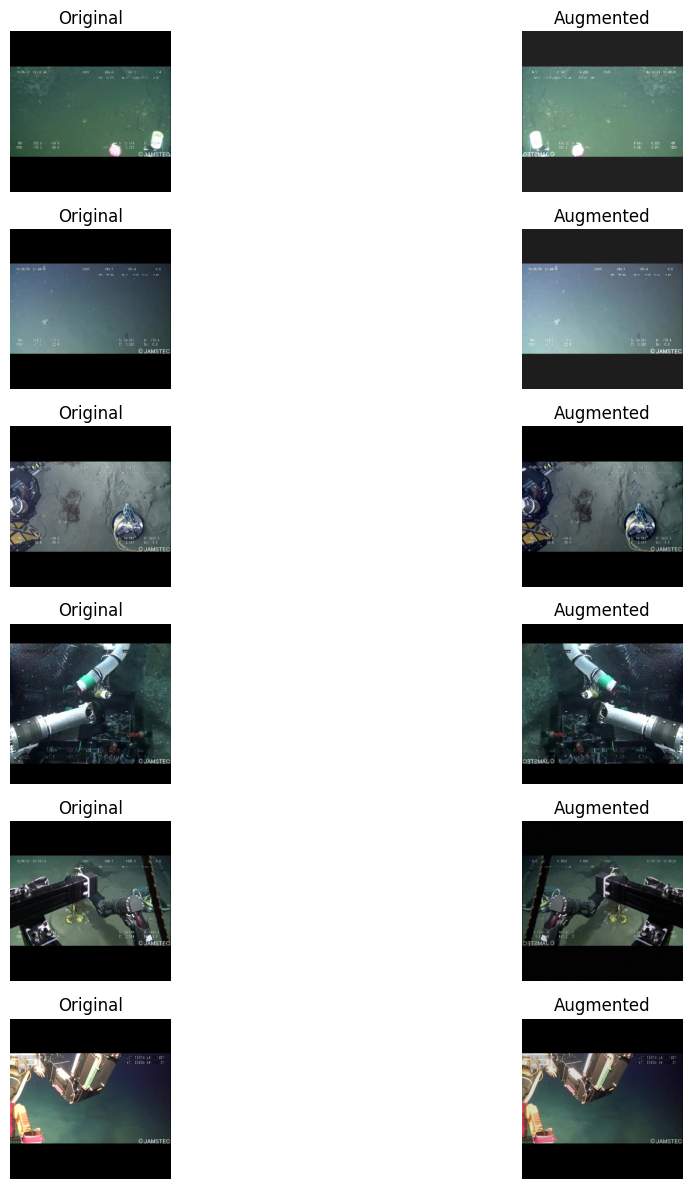

In [35]:
# Day 13 - Multi-image Augmentation Sanity Check
#
# We test the final augmentation policy on several different
# training images instead of relying on a single example.
#
# This helps us check whether the augmentations remain realistic
# across different underwater scenes and visibility conditions.
#
# IMPORTANT:
# This is only a visualization test. Dataset V1 is not modified.

import random
import cv2
import matplotlib.pyplot as plt

# Use a fixed random seed so that we can reproduce the same
# set of images later if needed.
random.seed(42)

# Select 6 different training images
sample_paths = random.sample(train_images, 6)

# Create the figure
plt.figure(figsize=(14, 12))

for i, image_path in enumerate(sample_paths):

    # Load image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply the final augmentation pipeline
    # only to the image for this visual sanity check.
    augmented_result = final_augmentation(image=img)

    augmented_img = augmented_result["image"]

    # Original image
    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Original")

    # Augmented image
    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(augmented_img)
    plt.axis("off")
    plt.title("Augmented")

plt.tight_layout()
plt.show()

In [36]:
# This cell records the important findings and decisions from
# the augmentation and dataset analysis performed today.
#
# It does not modify the dataset. It simply prints a concise
# experiment summary for reproducibility and later review.

print("=" * 60)
print("DAY 13 - AUGMENTATION & TRAINING PREPARATION SUMMARY")
print("=" * 60)

print("\nDATASET")
print("Dataset: TrashCAN material_version")
print("Version: Dataset V1")
print("Image size: 640 x 640")
print("Resize: Aspect-ratio preserving letterbox")

print("\nFINAL SPLIT")
print("Train images:", len(train_data["images"]))
print("Validation images:", len(val_data["images"]))
print("Test images:", len(test_data["images"]))

print("\nANNOTATIONS")
print("Train objects:", len(train_data["annotations"]))
print("Validation objects:", len(val_data["annotations"]))
print("Test objects:", len(test_data["annotations"]))

print("\nCLASS IMBALANCE")
print("Number of classes:", len(class_counts))
print("Most common:", max_class[0], "-", max_class[1])
print("Least common:", min_class[0], "-", min_class[1])
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

print("\nSMALL OBJECTS")
print("Objects smaller than 1% of image area:", small_count)
print(f"Small-object prevalence: {small_percentage:.2f}%")

print("\nAUGMENTATION")
print("Horizontal flip: Enabled")
print("Brightness/contrast: Enabled")
print("Hue/saturation: Enabled")
print("Mild Gaussian blur: Enabled, low probability")
print("Mild Gaussian noise: Enabled, low probability")

print("\nDISABLED AUGMENTATIONS")
print("Random cropping")
print("Vertical flipping")
print("Strong geometric distortion")

print("\nANNOTATION VERIFICATION")
print("Bounding-box transformation: Verified")
print("Segmentation transformation: Verified")
print("Photometric augmentation: Verified")
print("Object visibility after augmentation: Verified")

print("\nDATA SAFETY")
print("Validation augmentation: Disabled")
print("Test augmentation: Disabled")
print("Original Dataset V1: Preserved")

print("\nSTATUS")
print("Dataset V1 is ready for model-training preparation.")
print("=" * 60)

DAY 13 - AUGMENTATION & TRAINING PREPARATION SUMMARY

DATASET
Dataset: TrashCAN material_version
Version: Dataset V1
Image size: 640 x 640
Resize: Aspect-ratio preserving letterbox

FINAL SPLIT
Train images: 5177
Validation images: 943
Test images: 1092

ANNOTATIONS
Train objects: 9118
Validation objects: 1390
Test objects: 1828

CLASS IMBALANCE
Number of classes: 16
Most common: rov - 2565
Least common: animal_crab - 108
Imbalance ratio: 23.75x

SMALL OBJECTS
Objects smaller than 1% of image area: 3199
Small-object prevalence: 35.08%

AUGMENTATION
Horizontal flip: Enabled
Brightness/contrast: Enabled
Hue/saturation: Enabled
Mild Gaussian blur: Enabled, low probability
Mild Gaussian noise: Enabled, low probability

DISABLED AUGMENTATIONS
Random cropping
Vertical flipping
Strong geometric distortion

ANNOTATION VERIFICATION
Bounding-box transformation: Verified
Segmentation transformation: Verified
Photometric augmentation: Verified
Object visibility after augmentation: Verified

DATA S